In [8]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
data_path = os.path.join(str(Path(os.getcwd()).parents[1]), 'open-data/data')
print(os.listdir(data_path))
competitions_path = os.path.join(data_path, 'competitions.json')
events_path = os.path.join(data_path, 'events')
lineups_path = os.path.join(data_path, 'lineups')
matches_path = os.path.join(data_path,'matches')

['lineups', 'events', 'competitions.json', 'matches', 'three-sixty']


In [10]:
event_path = os.path.join(events_path, str(3890561) + '.json')
event_dict_list = json.load(open(event_path, 'r'))

In [11]:
event_dict_list[0]

{'id': '41bd60ac-9b2c-4cb8-85aa-23ae71825c1e',
 'index': 1,
 'period': 1,
 'timestamp': '00:00:00.000',
 'minute': 0,
 'second': 0,
 'type': {'id': 35, 'name': 'Starting XI'},
 'possession': 1,
 'possession_team': {'id': 175, 'name': 'Hoffenheim'},
 'play_pattern': {'id': 1, 'name': 'Regular Play'},
 'team': {'id': 175, 'name': 'Hoffenheim'},
 'duration': 0.0,
 'tactics': {'formation': 3421,
  'lineup': [{'player': {'id': 37972, 'name': 'Jens Grahl'},
    'position': {'id': 1, 'name': 'Goalkeeper'},
    'jersey_number': 13},
   {'player': {'id': 5537, 'name': 'Fabian Lukas Schär'},
    'position': {'id': 3, 'name': 'Right Center Back'},
    'jersey_number': 5},
   {'player': {'id': 9396, 'name': 'Ermin Bičakčić'},
    'position': {'id': 4, 'name': 'Center Back'},
    'jersey_number': 4},
   {'player': {'id': 12321, 'name': 'Tobias Strobl'},
    'position': {'id': 5, 'name': 'Left Center Back'},
    'jersey_number': 12},
   {'player': {'id': 9397, 'name': 'Pavel Kadeřábek'},
    'positi

In [ ]:
# 25 positions namely:
# GK - goalkeeper
# RB - right back
# RCB - right center back
# CB - center back
# LCB - left center back
# LB - left back
# RWB - right wing back
# LWB - left wing back
# RDM - right defensive midfield
# CDM - center defensive midfield
# LDM - Left defensive midfield
# RM - Right midfield
# RCM - Right center midfield
# CM - Center midfield
# LCM - left center midfield
# LM - Left midfield
# RW - right wing
# RAM - Right attacking midfield
# CAM - Center attacking midfield
# LAM - Left attacking midfield
# LW - left wing 
# RCF - right center forward
# ST - striker
# LCF - left center forward
# SS - secondary striker

In [12]:
competitions_df = pd.read_json(competitions_path)
competitions_df

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2023-08-17T23:51:11.837478,None,None,2023-08-17T23:51:11.837478
1,16,4,Europe,Champions League,male,False,False,2018/2019,2023-03-07T12:20:48.118250,2021-06-13T16:17:31.694,None,2023-03-07T12:20:48.118250
2,16,1,Europe,Champions League,male,False,False,2017/2018,2021-08-27T11:26:39.802832,2021-06-13T16:17:31.694,None,2021-01-23T21:55:30.425330
3,16,2,Europe,Champions League,male,False,False,2016/2017,2021-08-27T11:26:39.802832,2021-06-13T16:17:31.694,None,2020-07-29T05:00
4,16,27,Europe,Champions League,male,False,False,2015/2016,2021-08-27T11:26:39.802832,2021-06-13T16:17:31.694,None,2020-07-29T05:00
...,...,...,...,...,...,...,...,...,...,...,...,...
62,55,43,Europe,UEFA Euro,male,False,True,2020,2023-02-24T21:26:47.128979,2023-04-27T22:38:34.970148,2023-04-27T22:38:34.970148,2023-02-24T21:26:47.128979
63,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2023-06-18T19:28:39.443883,2021-06-13T16:17:31.694,None,2023-06-18T19:28:39.443883
64,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2023-07-17T21:19:03.032991,2023-07-17T21:21:56.497106,2023-07-17T21:21:56.497106,2023-07-17T21:19:03.032991
65,72,107,International,Women's World Cup,female,False,True,2023,2023-09-01T12:34:19.705316,2023-09-01T12:35:45.762196,2023-09-01T12:35:45.762196,2023-09-01T12:34:19.705316


In [13]:
unique_competition_id = competitions_df["competition_id"].unique()
unique_season_id = competitions_df["season_id"].unique()
match_id = []
match_date = []
kick_off = []
competition = []
season = []
home_team = []
away_team = []
home_score = []
away_score = []
match_status = []
match_status_360 = []
last_updated = []
last_updated_360 = []
meta_data = []
match_week = []
competition_stage = []
stadium = []
referee = []


for i in range(len(unique_competition_id)):
    for j in range(len(unique_season_id)):
        train_match_path = os.path.join(matches_path, str(unique_competition_id[i]) + '/' + str(unique_season_id[j]) + '.json')
        if (os.path.exists(train_match_path)):
            train_match_dict = json.load(open(train_match_path, 'r'))
            #try:
            for match in train_match_dict:
              match_id.append(match['match_id'])
              match_date.append(match['match_date'])
              kick_off.append(match['kick_off'])
              competition.append(match['competition'])
              season.append(match['season'])
              home_team.append(match['home_team'])
              away_team.append(match['away_team'])
              home_score.append(match['home_score'])
              away_score.append(match['away_score'])
              match_status.append(match['match_status'])
              match_status_360.append(match['match_status_360'])
              last_updated.append(match['last_updated'])
              last_updated_360.append(match['last_updated_360'])
              meta_data.append(match['metadata'])
              match_week.append(match['match_week'])
              competition_stage.append(match['competition_stage'])
              try: 
                stadium.append(match['stadium'])
              except KeyError:
                stadium.append(np.nan)
              try:
                referee.append(match["referee"])
              except KeyError:
                referee.append(np.nan)
            #except:
            #  print("No information for these competition/seasons")
            #  print(i,j)
            #  continue  #for cases that tthe json files are empty
            
matches_df = pd.DataFrame({'match_id': match_id,
                           'match_date': match_date,
                            'kick_off': kick_off,
                            'competition': competition,
                           'season': season,
                            'home_team': home_team,
                            'away_team': away_team,
                            'home_score': home_score,
                            'away_score': away_score,
                           'match_status': match_status,                           
                          'match_status_360': match_status_360,
                            'last_updated': last_updated,
                            'last_updated_360': last_updated_360,
                          'meta_data': meta_data,
                          'match_week': match_week,
                           'competition_stage': competition_stage,
                          'stadium': stadium,
                          'referee': referee})

matches_df

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,meta_data,match_week,competition_stage,stadium,referee
0,3890561,2016-05-14,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 175, 'home_team_name': 'Hoffe...","{'away_team_id': 181, 'away_team_name': 'Schal...",1,4,available,unscheduled,2023-07-24T07:47:12.510532,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",34,"{'id': 1, 'name': 'Regular Season'}","{'id': 4541, 'name': 'PreZero Arena', 'country...","{'id': 186, 'name': 'Felix Brych', 'country': ..."
1,3890505,2016-04-02,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 169, 'home_team_name': 'Bayer...","{'away_team_id': 184, 'away_team_name': 'Eintr...",1,0,available,unscheduled,2023-08-03T13:14:14.503553,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",28,"{'id': 1, 'name': 'Regular Season'}","{'id': 4867, 'name': 'Allianz Arena', 'country...","{'id': 1008758, 'name': 'Florian Meyer', 'coun..."
2,3890511,2016-04-08,20:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 173, 'home_team_name': 'Herth...","{'away_team_id': 178, 'away_team_name': 'Hanno...",2,2,available,unscheduled,2023-08-06T05:50:38.345688,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",29,"{'id': 1, 'name': 'Regular Season'}","{'id': 367, 'name': 'Olympiastadion Berlin', '...","{'id': 235, 'name': 'Benjamin Brand', 'country..."
3,3890515,2016-04-09,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 171, 'home_team_name': 'Hambu...","{'away_team_id': 872, 'away_team_name': 'Darms...",1,2,available,unscheduled,2023-07-18T17:52:17.363623,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",29,"{'id': 1, 'name': 'Regular Season'}","{'id': 379, 'name': 'Volksparkstadion', 'count...","{'id': 1008767, 'name': 'Peter Sippel', 'count..."
4,3890411,2015-12-20,16:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 27, 'season_name': '2015/2016'}","{'home_team_id': 173, 'home_team_name': 'Herth...","{'away_team_id': 177, 'away_team_name': 'FSV M...",2,0,available,unscheduled,2023-07-16T13:47:06.565811,None,"{'data_version': '1.1.0', 'shot_fidelity_versi...",17,"{'id': 1, 'name': 'Regular Season'}","{'id': 367, 'name': 'Olympiastadion Berlin', '...","{'id': 1008767, 'name': 'Peter Sippel', 'count..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3194,69199,2019-06-27,21:00:00.000,"{'competition_id': 72, 'country_name': 'Intern...","{'season_id': 30, 'season_name': '2019'}","{'home_team_id': 852, 'home_team_name': 'Norwa...","{'away_team_id': 865, 'away_team_name': 'Engla...",0,3,available,scheduled,2023-07-24T21:48:06.945119,2021-06-13T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",5,"{'id': 1, 'name': 'Regular Season'}","{'id': 230, 'name': 'Stade Océane', 'country':...","{'id': 1638, 'name': 'Lucila Venegas Montes', ..."
3195,69258,2019-07-02,21:00:00.000,"{'competition_id': 72, 'country_name': 'Intern...","{'season_id': 30, 'season_name': '2019'}","{'home_team_id': 865, 'home_team_name': 'Engla...","{'away_team_id': 1214, 'away_team_name': 'Unit...",1,2,available,scheduled,2023-07-27T10:32:52.092920,2021-06-13T16:17:31.694,"{'data_version': '1.1.0', 'shot_fidelity_versi...",6,"{'id': 15, 'name': 'Semi-finals'}","{'id': 193, 'name': 'Groupama Stadium', 'count...",NaN
3196,69284,2019-07-03,21:00:00.000,"{'competition_id': 72, 'country_name': 'Intern...","{'season_id': 30, 'season_name': '2019'}","{'home_team_id': 851, 'home_team_name': 'Nethe...","{'away_team_id': 858, 'away_team_name': 'Swede...",1,0,available,scheduled,2023-07-24T21:53:19.994655,2021-06-

In [15]:
# Transform all matches into tactics df to feed into the DL model: (report number of events for the home team)
# In total, there are 50 binary classes (only 14 of them are selectetd)
final_match_id = []
final_home_formation = []
final_home_position = [] # Need further separation (defensive = 0, offensive = 1)
final_away_formation = []
final_away_position = [] # Need further separation (defensive = 0, offensive = 1)
final_minute = []
final_ball_possession = [] # Here say rate, let's compute the percentage of possession per actions
final_goals = [] # plus minus if there is a goal

for id in matches_df["match_id"]:
    match_from_df = matches_df[matches_df["match_id"] == id]
    home_team = match_from_df["home_team"].values[0]["home_team_name"]
    away_team = match_from_df["away_team"].values[0]["away_team_name"]
    event_path = os.path.join(events_path, str(id) + '.json')
    event_dict_list = json.load(open(event_path, 'r'))

    # First task:
    current_minute  = 0
    home_possesion = 0
    possesion_total = 0
    current_goals = 0
    idx = 0

    # Second task:



    # General info about the match
    for event in event_dict_list:
        if event["type"]["name"] == "Starting XI":
            if event["team"]["name"] == home_team:
                current_home_formation = event["tactics"]["formation"]
                current_home_pos = [x["position"]["id"] for x in event["tactics"]["lineup"]]
            elif event["team"]["name"] == away_team:
                current_away_formation = event["tactics"]["formation"]
                current_away_pos = [x["position"]["id"] for x in event["tactics"]["lineup"]]

        if event["type"]["name"] == "Tactical Shift":
            # Update the tactics df
            final_match_id.append(id)
            final_home_formation.append(current_home_formation)
            final_home_position.append(current_home_pos)
            final_away_formation.append(current_away_formation)
            final_away_position.append(current_away_pos)
            final_minute.append(current_minute)
            final_ball_possession.append(home_possesion/possesion_total)
            final_goals.append(current_goals)

            # Reset the attributes:
            possesion_calculation = 0
            current_goals = 0
            home_possesion = 0
            possesion_total = 0

            if event["team"]["name"] == home_team:
                # Update the new change for tactics:
                current_home_formation = event["tactics"]["formation"]
                current_home_pos = [x["position"]["id"] for x in event["tactics"]["lineup"]]
                current_minute = event["minute"]
                

            elif event["team"]["name"] == away_team:
                current_away_formation = event["tactics"]["formation"]
                current_away_pos = [x["position"]["id"] for x in event["tactics"]["lineup"]]
                current_minute = event["minute"]
    

        
        if len(event_dict_list) == idx - 1:
            final_home_formation.append(current_home_formation)
            final_home_position.append(current_home_pos)
            final_away_formation.append(current_away_formation)
            final_away_position.append(current_away_pos)
            final_minute.append(current_minute)
            final_ball_possession.append(home_possesion/possesion_total)
            final_goals.append(current_goals)
        

        if event["type"]["name"] == "Own Goal For":
            if event["team"]["name"] == home_team:
                current_goals += 1
            elif event["team"]["name"] == away_team:
                current_goals -= 1
        
        if event["type"]["name"] == "Shot":
            if event["shot"]["outcome"]["name"] == 'Goal':
                if event["team"]["name"] == home_team:
                    current_goals += 1
                elif event["team"]["name"] == away_team:
                    current_goals -= 1
        
    
        if event["possession_team"]["name"] == home_team:
            home_possesion += 1
            possesion_total += 1
        elif event["possession_team"]["name"] == away_team:
            possesion_total += 1

        idx += 1
        

        
tactics_df = pd.DataFrame({'home_formation': final_home_formation,
                           'home_position': final_home_position,
                           'away_formation': final_away_formation,
                           'away_position': final_away_position,
                           'minute': final_minute,
                           'ball_possession': final_ball_possession,
                           'home_goal': final_goals})

In [198]:
tactics_df

,home_formation,home_position,away_formation,away_position,minute,ball_possession,home_goal
0,3421,"[1, 3, 4, 5, 7, 8, 9, 11, 18, 20, 23]",4141,"[1, 2, 3, 5, 6, 10, 12, 13, 15, 16, 23]",0,0.460870,-2
1,433,"[1, 2, 3, 5, 6, 10, 13, 15, 17, 21, 23]",4141,"[1, 2, 3, 5, 6, 10, 12, 13, 15, 16, 23]",26,0.446927,1
2,433,"[1, 2, 3, 5, 6, 10, 13, 15, 17, 21, 23]",4141,"[1, 2, 3, 5, 6, 10, 12, 13, 15, 16, 23]",45,0.413235,-1
3,442,"[1, 2, 3, 5, 6, 9, 11, 12, 16, 22, 24]",4141,"[1, 2, 3, 5, 6, 10, 12, 13, 15, 16, 23]",59,0.423133,-1
4,433,"[1, 2, 3, 5, 6, 10, 13, 15, 17, 21, 23]",343,"[1, 3, 4, 5, 7, 8, 9, 11, 17, 21, 23]",0,0.690789,1
...,...,...,...,...,...,...,...
7729,4231,"[1, 2, 3, 5, 6, 9, 11, 17, 19, 21, 23]",433,"[1, 2, 3, 5, 6, 10, 13, 15, 17, 21, 23]",0,0.594908,-1
7730,4231,"[1, 2, 3, 5, 6, 9, 11, 17, 19, 21, 23]",433,"[1, 2, 3, 5, 6, 10, 13, 15, 17, 21, 23]",62,0.612583,0
7731,4231,"[1, 2, 3, 5, 6, 9, 11, 17, 19, 21, 23]",343,"[1, 3, 4, 5, 7, 8, 13, 15, 17, 21, 23]",73,0.591623,0
7732,442,"[1, 2, 3, 5, 6, 12, 13, 15, 16, 22, 24]",433,"[1, 2, 3, 5, 6, 10, 13, 15, 17, 21, 23]",0,0.351962,-2


In [119]:
# check pytorch version and train DL models
import torch
print(torch.__version__)

2.1.1+cu121


In [120]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torch import Tensor
from torch.nn import Linear
from torch.nn import ReLU
from torch.nn import Sigmoid
from torch.nn import Module

In [113]:
home_for = []
for vector in tactics_df["home_formation"].to_list():
     str_convert = np.array([int(i) for i in str(vector)])
     home_for.append(np.hstack([str_convert, np.zeros(6-len(str_convert), dtype=int)]))

np.array(home_for)

array([[3, 4, 2, 1, 0, 0],
       [4, 3, 3, 0, 0, 0],
       [4, 3, 3, 0, 0, 0],
       ...,
       [4, 2, 3, 1, 0, 0],
       [4, 4, 2, 0, 0, 0],
       [4, 3, 3, 0, 0, 0]])

In [82]:
f_class = np.array(range(1,26))
position = []
for vector in tactics_df["home_position"].to_list():
    position.append([int(u in vector) for u in f_class])

np.array(position)

array([[1, 0, 1, ..., 1, 0, 0],
       [1, 1, 1, ..., 1, 0, 0],
       [1, 1, 1, ..., 1, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 0, 0],
       [1, 1, 1, ..., 0, 1, 0],
       [1, 1, 1, ..., 1, 0, 0]])

In [294]:
def convert_to_torch_input(dataframe):
    # Necessary inputs: home, away, ball_poss, min, for_h_a -> Tensors

    # Binary input: home, away from 25 classes
    f_class = np.array(range(1,26))
    home_position = []
    away_position = []
    for vector in tactics_df["home_position"].to_list():
        home_position.append([int(u in vector) for u in f_class])
    for vector in tactics_df["away_position"].to_list():
        away_position.append([int(u in vector) for u in f_class])
    home_pos = torch.tensor(np.array(home_position)).to(torch.float32)
    away_pos = torch.tensor(np.array(away_position)).to(torch.float32)

    # Continous input: ball_poss, min
    ball_pos = dataframe["ball_possession"].values
    minute = dataframe["minute"].values
    continuous = torch.tensor(np.vstack((ball_pos,minute)).T).to(torch.float32)
    
    # Category input: for_h, for_a:
    home_for = []
    away_for = []
    for vector in tactics_df["home_formation"].to_list():
        str_convert = np.array([int(i) for i in str(vector)])
        home_for.append(np.hstack([str_convert, np.zeros(6-len(str_convert), dtype=int)]))

    for vector in tactics_df["away_formation"].to_list():
        str_convert = np.array([int(i) for i in str(vector)])
        away_for.append(np.hstack([str_convert, np.zeros(6-len(str_convert), dtype=int)]))

    h_for = torch.LongTensor(np.array(home_for))
    a_for = torch.LongTensor(np.array(away_for))

    # y_label:
    y = []
    for element in dataframe["home_goal"].values:
        if element < 0:
            y.append(np.array([1,0,0]))
        elif element == 0:
            y.append(np.array([0,1,0]))
        elif element > 0:
            y.append(np.array([0,0,1]))

    y = torch.Tensor(np.array(y))

    return home_pos, away_pos, continuous, h_for, a_for, y
    

In [133]:
# ensure input data is floats
#self.X = self.X.astype('float32')
# label encode target and ensure the values are floats
# self.y = LabelEncoder().fit_transform(self.y)
# self.y = self.y.astype('float32')
# self.y = self.y.reshape((len(self.y), 1))

torch.Size([7734])

In [141]:
len(convert_to_torch_input(tactics_df)[0][0])

25

In [295]:
# dataset definition
class PD_Dataset(Dataset):
    # load the dataset
    def __init__(self, df):
        # get Tensors from tactics_df
        self.home_pos, self.away_pos, self.continuous, self.h_for, self.a_for, self.y = convert_to_torch_input(df)
        
    # number of rows in the dataset
    def __len__(self):
        return len(self.home_pos)
 
    # get a row at an index
    def __getitem__(self, idx):
        return [self.home_pos[idx], self.away_pos[idx], self.continuous[idx], self.h_for[idx], self.a_for[idx], self.y[idx]]
 
    # get indexes for train and test rows
    def get_splits(self, n_test=0.33):
        # determine sizes
        test_size = round(n_test * len(self.home_pos))
        train_size = len(self.home_pos) - test_size
        # calculate the split
        return random_split(self, [train_size, test_size])
    

In [308]:
class MLP_MOS(Module):
    # home: binary representation of all 25 var for home team
    # away: binary representation of all 25 var for away team
    # ball_pos: possesion rate for the home team
    # for_h: formation of home team
    # for_w: formation of away team
    def __init__(self):
        super(MLP_MOS, self).__init__()
        # Output_home/away position
        self.proj_layer = torch.nn.Linear(25, 400)
        self.continous_layer = torch.nn.Sequential(torch.nn.Linear(2, 32),torch.nn.Linear(32,32),torch.nn.Linear(32,32))
        num_classes = 27 
        embedding_size = 16
        self.embedding = torch.nn.Embedding(num_classes,embedding_size)
        
        # Define the 3 paths for 3 outputs:
        self.layer1 = torch.nn.Sequential(torch.nn.Linear(1056,42),
                                          torch.nn.ReLU(),
                                          torch.nn.Dropout(p = 0.2),
                                          torch.nn.BatchNorm1d(num_features = 42))
        self.layer2 =  torch.nn.Sequential(torch.nn.Linear(42,42),
                                            torch.nn.ReLU())

        self.layer3 = torch.nn.Sequential(torch.nn.Linear(42,24),
                                          torch.nn.ReLU())
        self.layer4 = torch.nn.Sequential(torch.nn.Linear(24,12),
                                          torch.nn.ReLU())

        self.soft_1 = torch.nn.Sequential(torch.nn.Linear(42,25),
                                          torch.nn.Softmax())
        self.soft_2 = torch.nn.Sequential(torch.nn.Linear(42,2),
                                          torch.nn.Softmax())
        self.soft_3 = torch.nn.Sequential(torch.nn.Linear(12,3),
                                          torch.nn.Softmax())

    def forward(self, batch):
            
        home_pos, away_pos, continous, h_for, a_for = batch
        # Prepare the binary features for projection_home
        self.output_home = self.proj_layer(home_pos)
        self.output_away = self.proj_layer(away_pos)

        # Prepare the continuous features for 3x projection:
        self.possession = self.continous_layer(continous)
        self.minute = self.continous_layer(continous)

        # Prepare the embedding vector for formation:
        self.output_for_h = torch.flatten(self.embedding(h_for), start_dim = 1)
        self.output_for_a = torch.flatten(self.embedding(a_for), start_dim = 1)

        # Concat the all the vectors together
        X_0 = torch.cat((self.output_home,self.output_away,self.possession, self.minute, self.output_for_h, self.output_for_a), dim = 1)
        # first output:
        x_1 = self.layer1(X_0)
        x_1 = self.layer2(x_1) + x_1
        x_1 = self.soft_1(x_1)

        # second output:
        x_2 = self.layer1(X_0)
        x_2 = self.layer2(x_2) + x_2
        x_2 = self.soft_2(x_2) 

        # third output:
        x_3 = self.layer1(X_0)
        x_3 = self.layer2(x_3)
        x_3 = self.layer3(x_3)
        x_3 = self.layer4(x_3)
        x_3 = self.soft_3(x_3)

        return x_1, x_2, x_3
        
        

In [297]:
# prepare the dataset
def prepare_data():
    # load the dataset
    dataset = PD_Dataset(tactics_df)
    # calculate split
    train, test = dataset.get_splits()
    # prepare data loaders
    train_dl = DataLoader(train, batch_size=32, shuffle=True)
    test_dl = DataLoader(test, batch_size=1024, shuffle=False)
    return train_dl, test_dl

In [302]:
# train the model
def train_model(train_dl, model):
    # define the optimization
    

In [303]:
# evaluate the model
def evaluate_model(test_dl, model):
    predictions, actuals = list(), list()
    for i, (home_pos, away_pos, continuous, h_for, a_for, y) in enumerate(test_dl):
        # evaluate the model on the test set
        batch = home_pos, away_pos, continuous, h_for, a_for
        yhat1, yhat2, yhat3 = model(batch)
        # retrieve numpy array
        print(i)
        print("Win_Loss_Draw probability:")
        print(yhat3 = yhat3.detach().numpy())
        print("True event:")
        print(y)

In [304]:
import torch

if torch.cuda.is_available():
    print("CUDA is available. Training on GPU.")
else:
    print("CUDA is not available. Training on CPU.")

CUDA is available. Training on GPU.


In [317]:
temp = None
train_dl, test_dl = prepare_data()
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP_MOS()
model = model.to(device)
print(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01, weight_decay= 0.001) 
average_loss_list = []

epochs = 100
for epoch in range(epochs):
    # enumerate mini batches
    total_loss = 0

    for i, (home_pos, away_pos, continuous, h_for, a_for, y) in enumerate(train_dl):
    
        home_pos, away_pos, continuous, h_for, a_for, y = home_pos.to(device), away_pos.to(device), continuous.to(device), h_for.to(device), a_for.to(device), y.to(device)
        batch = home_pos, away_pos, continuous, h_for, a_for
        # clear the gradients
        optimizer.zero_grad()
        # compute the model output
        y_1, y_2, y_3 = model(batch)
        # calculate loss
        loss = criterion(y_3,y)
        # credit assignment
        loss.backward()
        # update model weights
        optimizer.step()

        total_loss += loss.item()
    
    average_loss = total_loss/len(train_dl)
    average_loss_list.append(average_loss)



cuda


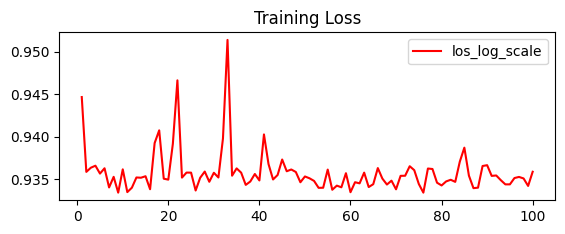

In [318]:
plt.subplot(2,1,1)
plt.plot(range(1,epochs+1), average_loss_list, color = 'red', label = 'los_log_scale')
plt.title("Training Loss")
plt.legend()